### v0.83：完全重构class VirtualCell<br>0.831：2阶段运行<br>0.832：体积约束<br>0.833:侧壁法向排斥力、减小铺展力阈值、添加沟槽侧壁防穿透<br>0.84:重新使用FENE<br>0.841：修正弯曲力<br>0.842修改下降逻辑

In [1]:
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
import gmsh
import sys
from IPython.display import display, clear_output

In [2]:
# 1. 物理常数与参数配置 (Strictly based on Table S1 & Note)
# ============================================================================
version = 'v0.842_FENE_descenting_fix'
kBT = 1.0 
# alpha 是长度单位，模拟中设为 1.0，所有长度参数相对于 alpha 定义
alpha = 1.0 # 基本单位：能量 kBT, 长度 a (平均键长)

PARAMS = {
    # --- Geometrical Parameters (Table S1 - Figure 1) ---
    'R_cell': 11.0 * alpha,
    'R_nucleus': 3.4 * alpha,
    'groove_width': 6 * alpha,#4.0      
    'groove_depth': 1.5 * alpha, #0.9     
    'ridge_fraction':0.30,
    'wall_fraction':0.08,
    # --- Membrane Parameters (Eq 1) ---
    # 根据 MD 文档：l_max = 1.33a, l_min = 0.67a, l_c0 = 1.15a, l_c1 = 0.85a
    'b': 80.0 * kBT,
    'l_max': 1.33 * alpha,
    'l_min': 0.67 * alpha,
    'l_c0': 1.15 * alpha,  # 临界伸长长度，超过此长度势能爆炸
    'l_c1': 0.85 * alpha,  # 临界压缩长度，低于此长度势能爆炸
    
    'k_curve': 20.0 * kBT,             # Bending Energy
    'k_area_s': 1.0 * kBT / (alpha**4), # Area Constraint
    'F_active': 30.0 * kBT / alpha,    # Active Spreading Force
    
    # --- Cytoskeleton Parameters (Eq 2) ---
    'k_0': 1.0 * kBT / (alpha**2),
    'k_cyt': 1.0 * 1.0 * kBT / (alpha**2), 
    'mu_0': 100.0, # Viscosity (Eq 3)
    
    # --- Chromatin Parameters (Eq 5) ---
    'N_chains': 5,
    'N_beads': 500, 
    'sigma_ch': 0.6 * alpha,
    'k_chrom_bond': 100.0 * kBT, 
    'k_chrom_bend': 5.0 * kBT,   
    'epsilon_ch': 1.0 * kBT,
    
    # --- Simulation ---
    'gamma': 20.0, # Damping
    'dt': 0.001,  # 时间步长，Gmsh网格质量好，可以适当增加dt，但为了保守起见保持较小
    'max_force': 2000.0 
}

In [15]:
# ====================== 完整修复版 VirtualCell (v0.92) ======================
# 严格符合 METHODS Eq1~Eq6 + Table S1 Figure1
# 已修复：缺失方法、face_normals作用域、cyto_force_scalar保存、染色质完整力、bending稳定性
# 细胞会从上方自然沉降 → 接触沟槽 → 沿Y轴明显拉伸 + 膜皱褶

class VirtualCell:
    def __init__(self, n_cyto=3000):
        print(f"Canceling chromatin & cyto")
        
        # 1. Gmsh 几何
        self.pos_mem, self.mem_tris = self.generate_sphere_gmsh(PARAMS['R_cell'], alpha)
        self.pos_nuc, self.nuc_tris_local = self.generate_sphere_gmsh(PARAMS['R_nucleus'], alpha)
        
        n_mem = len(self.pos_mem)
        n_nuc = len(self.pos_nuc)
        print(f"Gmsh: Membrane {n_mem} nodes, Nucleus {n_nuc} nodes")
        
        # 2. Cytoplasm + Chromatin
        self.pos_cyto = self._generate_cytoplasm(n_cyto)
        self.chrom_chains, self.pos_chrom = self._generate_chromatin(n_mem + n_nuc + n_cyto)
        
        # 3. 合并 + 索引
        self.positions = np.vstack((self.pos_mem, self.pos_nuc, self.pos_cyto, self.pos_chrom))
        self.forces = np.zeros_like(self.positions)
        self._build_indices(n_mem, n_nuc, n_cyto, len(self.pos_chrom))
        
        # 4. 拓扑
        self.mem_edges = self._tris_to_edges(self.mem_tris)
        self.nuc_tris = self.nuc_tris_local + n_mem
        self.nuc_edges = self._tris_to_edges(self.nuc_tris_local) + n_mem
        self.cyto_edges = self._build_cyto_edges()          # ← 新增(cancel)
        self.chrom_bonds = self._build_chrom_bonds()        # ← 新增(cancel)

        #预松弛
        self._pre_relax_mesh(iterations=500)
        
        # 5. 初始量
        self.S0_mem = self._calculate_area(self.mem_tris)
        self.S0_nuc = self._calculate_area(self.nuc_tris)
        self.mem_hinges = self._build_hinges(self.mem_tris)
        self.cos0_mem = self._calculate_initial_cos_angles(self.mem_hinges)#计算初始二面角
        self.cyto_rest_len = np.linalg.norm(
            self.positions[self.cyto_edges[:,0]] - self.positions[self.cyto_edges[:,1]], axis=1)
        
        # 6. 阶段控制
        #self.relax_mesh_springs()
        self.substrate_active = False   # Phase 1 时关闭基底力
        #self.relax_mesh_springs()
        # 7. 体积约束
        self.V0_mem = self._calculate_volume(self.mem_tris)
        # 8. 初始化步数
        self._step_count = 0

        #self.cyto_force_scalar = np.array([])#cyto_cancel测试

    # ====================== 辅助方法（完整保留） ======================
    def generate_sphere_gmsh(self, radius, target_edge_length):
        gmsh.initialize()
        gmsh.model.add("sphere_model")
        gmsh.model.occ.addSphere(0, 0, 0, radius, 1)
        gmsh.model.occ.synchronize()
        gmsh.option.setNumber("Mesh.CharacteristicLengthMin", target_edge_length)
        gmsh.option.setNumber("Mesh.CharacteristicLengthMax", target_edge_length)
        gmsh.option.setNumber("Mesh.Algorithm", 6)
        gmsh.model.mesh.generate(2)
        nodeTags, nodeCoords, _ = gmsh.model.mesh.getNodes()
        positions = np.array(nodeCoords).reshape(-1, 3)
        triTags, triNodeTags = gmsh.model.mesh.getElementsByType(2)
        triangles = np.array(triNodeTags).reshape(-1, 3)
        tag_to_idx = {tag: i for i, tag in enumerate(nodeTags)}
        mapped_tris = np.array([[tag_to_idx[n] for n in tri] for tri in triangles])
        gmsh.finalize()
        return positions, mapped_tris

    def _generate_cytoplasm(self, n_cyto):
        pos = []
        for _ in range(n_cyto):
            r = (PARAMS['R_nucleus'] + (PARAMS['R_cell']-PARAMS['R_nucleus']) * np.random.rand()**(1/3))
            theta = np.random.rand() * 2 * np.pi
            phi = np.arccos(2*np.random.rand() - 1)
            pos.append([r * np.sin(phi) * np.cos(theta),
                        r * np.sin(phi) * np.sin(theta),
                        r * np.cos(phi)])
        return np.array(pos)

    def _generate_chromatin(self, offset):
        chrom_chains = []
        chrom_points = []
        for c in range(PARAMS['N_chains']):
            chain = []
            start = np.array([0.,0.,0.]) + np.random.randn(3)*0.5
            for b in range(PARAMS['N_beads']):
                chrom_points.append(start.copy())
                chain.append(offset)
                offset += 1
                start += np.random.randn(3) * PARAMS['sigma_ch']
            chrom_chains.append(chain)
        return chrom_chains, np.array(chrom_points)

    def _build_indices(self, n1, n2, n3, n4):
        self.idx_mem = np.arange(0, n1)
        self.idx_nuc = np.arange(n1, n1+n2)
        self.idx_cyto = np.arange(n1+n2, n1+n2+n3)
        self.idx_chrom = np.arange(n1+n2+n3, n1+n2+n3+n4)

    def _tris_to_edges(self, tris):
        edges = set()
        for t in tris:
            edges.add(tuple(sorted((t[0], t[1]))))
            edges.add(tuple(sorted((t[1], t[2]))))
            edges.add(tuple(sorted((t[0], t[2]))))
        return np.array(list(edges))

    def _build_hinges(self, tris):
        edge_to_tris = {}
        for idx, tri in enumerate(tris):
            for i, j in [(0,1),(1,2),(2,0)]:
                edge = tuple(sorted((tri[i], tri[j])))
                if edge not in edge_to_tris: edge_to_tris[edge] = []
                edge_to_tris[edge].append(idx)
        hinges = []
        for edge, idxs in edge_to_tris.items():
            if len(idxs) == 2:
                t1, t2 = tris[idxs[0]], tris[idxs[1]]
                u, v = edge
                op1 = [x for x in t1 if x != u and x != v][0]
                op2 = [x for x in t2 if x != u and x != v][0]
                hinges.append([op1, u, v, op2])
        return np.array(hinges)

    def _calculate_area(self, tris):
        p1 = self.positions[tris[:,0]]
        p2 = self.positions[tris[:,1]]
        p3 = self.positions[tris[:,2]]
        cross = np.cross(p2-p1, p3-p1)
        return 0.5 * np.sum(np.linalg.norm(cross, axis=1))

    def _build_cyto_edges(self):# ← 缺失方法补全（Delaunay）
        #return np.array([]).reshape(0, 2).astype(int)
        
        points_for_tess = self.positions[:len(self.idx_mem)+len(self.idx_nuc)+len(self.pos_cyto)]
        delaunay = Delaunay(points_for_tess)
        edges = set()
        for s in delaunay.simplices:
            for i in range(4):
                for j in range(i+1, 4):
                    u, v = s[i], s[j]
                    if u in self.idx_cyto or v in self.idx_cyto:
                        edges.add(tuple(sorted((u, v))))
        return np.array(list(edges))
        
    def _build_chrom_bonds(self):  # ← 缺失方法补全
        bonds = []
        for chain in self.chrom_chains:
            for i in range(len(chain)-1):
                bonds.append([chain[i], chain[i+1]])
        return np.array(bonds)
        
    def relax_mesh_springs(self):
        print(">>> Pre-relaxing mesh with Hookean springs...")
        for _ in range(100):
            self.forces[:] = 0.0
            for edges in [self.mem_edges, self.nuc_edges]:
                idx1, idx2 = edges[:,0], edges[:,1]
                vec = self.positions[idx2] - self.positions[idx1]
                dist = np.linalg.norm(vec, axis=1)
                force_mag = 50.0 * (dist - alpha)
                force_vec = (vec / (dist[:,None] + 1e-9)) * force_mag[:,None]
                np.add.at(self.forces, idx1, force_vec)
                np.add.at(self.forces, idx2, -force_vec)
            self.positions += 0.001 * self.forces
            d_mem = np.linalg.norm(self.positions[self.idx_mem], axis=1)
            self.positions[self.idx_mem] *= (PARAMS['R_cell'] / d_mem[:,None])
            d_nuc = np.linalg.norm(self.positions[self.idx_nuc], axis=1)
            self.positions[self.idx_nuc] *= (PARAMS['R_nucleus'] / d_nuc[:,None])
        print(">>> Relaxation complete.")

    def place_cell_above_substrate(self, clearance=0.5):
        z_sub_max = 0.0
        min_mem_z = np.min(self.positions[self.idx_mem, 2])
        shift_z = z_sub_max - min_mem_z + clearance + 0.8
        self.positions[:, 2] += shift_z
        p1 = self.positions[self.cyto_edges[:,0]]
        p2 = self.positions[self.cyto_edges[:,1]]
        self.cyto_rest_len = np.linalg.norm(p1 - p2, axis=1)
        self.substrate_active = True # ← 开启基底力
        print(f">>> Phase 2: Cell placed {shift_z:.2f}α ABOVE substrate → substrate forces ON")

    # ====================== 核心 compute_forces ======================
    def compute_forces(self):
        self.forces[:] = 0.0
        self._membrane_bond_repulsion()
        self._membrane_bending()
        self._membrane_area_constraint()
        self._membrane_volume_constraint()  # 新增体积限制
        #self._active_spreading_and_settling()
        self._cytoskeleton_forces()#cancel
        #self._substrate_interaction()
        self._chromatin_forces()#cancel
        

        if self.substrate_active:
            f_before = self.forces.copy()
            self._substrate_interaction()
            f_substrate = np.linalg.norm(self.forces - f_before, axis=1).max()
            f_before = self.forces.copy()
            
            self._groove_wall_repulsion()
            self._active_spreading_and_settling()
            f_active = np.linalg.norm(self.forces - f_before, axis=1).max()
            
            # 核+骨架 硬墙排斥
            internal_idx = np.concatenate([self.idx_nuc, self.idx_cyto])
            int_pos = self.positions[internal_idx]
            int_sub_z = np.array([self.get_substrate_z(x) for x in int_pos[:, 0]])
            int_dist = int_pos[:, 2] - int_sub_z
            
            safety_gap = 1.0 * alpha
            pen_mask = int_dist < safety_gap
            if np.any(pen_mask):
                f_wall = 500.0 * kBT / alpha * (safety_gap - int_dist[pen_mask])
                self.forces[internal_idx[pen_mask], 2] += f_wall
            
            if self._step_count % 1000 == 0:
                print(f"  Substrate force max: {f_substrate:.2f}")
                print(f"  Active force max: {f_active:.2f}")

                z_sub = np.array([self.get_substrate_z(x) for x in self.positions[self.idx_mem, 0]])
                dz = self.positions[self.idx_mem, 2] - z_sub
                n_contact = np.sum(dz < 3.0)
                print(f"  Nodes near substrate (dz < 3α): {n_contact}")
                
        

    # ------------------- Eq1 -------------------
    '''
    def _membrane_bond_repulsion(self):
        l_c0 = PARAMS['l_c0']; l_c1 = PARAMS['l_c1']
        l_max = PARAMS['l_max']; l_min = PARAMS['l_min']
        b = PARAMS['b']
        
        #for edges in [self.mem_edges, self.nuc_edges]:
            #idx1, idx2 = edges[:,0], edges[:,1]
            #vec = self.positions[idx2] - self.positions[idx1]
            #r = np.linalg.norm(vec, axis=1)
            #d0 = np.clip(l_c0 - r, 0.001, 0.5)
            #d1 = np.clip(r - l_c1, 0.001, 0.5)
            #denom0 = np.clip(l_max - r, 0.01, 2.0)
            #denom1 = np.clip(r - l_min, 0.01, 2.0)
            #f_bond = b * np.exp(np.clip(1/d0, -20, 20)) * (1/(d0**2*denom0) + 1/denom0**2)
            #f_rep  = -b * np.exp(np.clip(1/d1, -20, 20)) * (1/(d1**2*denom1) + 1/denom1**2)
            #f_total = np.clip(f_bond + f_rep, -PARAMS['max_force'], PARAMS['max_force'])
            #f_vec = (vec / (r[:,None]+1e-9)) * f_total[:,None]
            #np.add.at(self.forces, idx1, f_vec)
            #np.add.at(self.forces, idx2, -f_vec)
        
        # 定义安全区间（指数势有效的区间）
        safe_margin = 0.25 * alpha  # 距离临界点的安全边距0.08、0.25、
        l_safe_upper = l_c0 - safe_margin  # ~1.07
        l_safe_lower = l_c1 + safe_margin  # ~0.93
        
        for edges in [self.mem_edges, self.nuc_edges]:
            idx1, idx2 = edges[:,0], edges[:,1]
            vec = self.positions[idx2] - self.positions[idx1]
            r = np.linalg.norm(vec, axis=1)
            direction = vec / (r[:,None] + 1e-9)
            
            f_total = np.zeros(len(r))
            
            # === 区域1: 安全区 (l_safe_lower < r < l_safe_upper) ===
            # 使用原始指数势
            safe_mask = (r > l_safe_lower) & (r < l_safe_upper)
            if np.any(safe_mask):
                r_safe = r[safe_mask]
                d0 = np.clip(l_c0 - r_safe, 0.01, 0.5)
                d1 = np.clip(r_safe - l_c1, 0.01, 0.5)
                denom0 = np.clip(l_max - r_safe, 0.05, 2.0)
                denom1 = np.clip(r_safe - l_min, 0.05, 2.0)
                
                f_bond = b * np.exp(np.clip(1/d0, -10, 10)) * (1/(d0**2*denom0) + 1/denom0**2)
                f_rep = -b * np.exp(np.clip(1/d1, -10, 10)) * (1/(d1**2*denom1) + 1/denom1**2)
                f_total[safe_mask] = f_bond + f_rep
            
            # === 区域2: 拉伸临界区 (r >= l_safe_upper) ===
            # 使用强 Hookean 弹簧拉回
            stretch_mask = r >= l_safe_upper
            if np.any(stretch_mask):
                r_stretch = r[stretch_mask]
                # 强回复力，将键长拉回到 l_safe_upper
                deviation = r_stretch - l_safe_upper
                k_stretch = 2000.0 * kBT / alpha**2 * (1 + 10 * deviation / alpha) #增强到2000
                #f_total[stretch_mask] = k_stretch * (r_stretch - l_safe_upper)
                f_total[stretch_mask] = k_stretch * deviation
            
            # === 区域3: 压缩临界区 (r <= l_safe_lower) ===
            # 使用强 Hookean 弹簧推开
            compress_mask = r <= l_safe_lower
            if np.any(compress_mask):
                r_compress = r[compress_mask]
                deviation = r_compress - l_safe_lower  # 负值
                #k_compress = 500.0 * kBT / alpha**2
                k_compress = 2000.0 * kBT / alpha**2 * (1 + 10 * np.abs(deviation) / alpha)
                #f_total[compress_mask] = k_compress * (r_compress - l_safe_lower)
                f_total[compress_mask] = k_compress * deviation
            
            # 限制最大力
            f_total = np.clip(f_total, -PARAMS['max_force'], PARAMS['max_force'])
            
            f_vec = direction * f_total[:,None]
            np.add.at(self.forces, idx1, f_vec)
            np.add.at(self.forces, idx2, -f_vec)
    '''        
    def _membrane_bond_repulsion(self):#FENE
        """纯 FENE 势"""
        l_eq = 1.0 * alpha
        R0 = 0.25 * alpha
        k_fene = 30.0 * kBT / alpha**2  # 可调
        
        for edges in [self.mem_edges, self.nuc_edges]:
            idx1, idx2 = edges[:,0], edges[:,1]
            vec = self.positions[idx2] - self.positions[idx1]
            r = np.linalg.norm(vec, axis=1)
            direction = vec / (r[:,None] + 1e-9)
            
            dr = r - l_eq
            dr_clipped = np.clip(dr, -0.95*R0, 0.95*R0)
            ratio_sq = (dr_clipped / R0) ** 2
            f_mag = -k_fene * dr_clipped / (1 - ratio_sq)
            
            out_of_range = np.abs(dr) > 0.95 * R0
            if np.any(out_of_range):
                k_hard = 500.0 * kBT / alpha**2
                f_mag[out_of_range] = -k_hard * dr[out_of_range]
            
            f_vec = direction * f_mag[:,None]
            np.add.at(self.forces, idx1, f_vec)
            np.add.at(self.forces, idx2, -f_vec)
            
    def _calculate_initial_cos_angles(self, hinges):
        """计算每个铰链的初始 cos 角度"""
        cos_angles = []
        for h in hinges:
            a, b, c, d = h
            pa, pb, pc, pd = self.positions[[a, b, c, d]]
            n1 = np.cross(pb - pa, pc - pa)
            n1 /= np.linalg.norm(n1) + 1e-9
            n2 = np.cross(pc - pd, pb - pd)
            n2 /= np.linalg.norm(n2) + 1e-9
            cos_angles.append(np.dot(n1, n2))
        return np.array(cos_angles)

    
    def _membrane_bending(self):
        k = PARAMS['k_curve']
        for i, h in enumerate(self.mem_hinges):
            a,b,c,d = h
            pa,pb,pc,pd = self.positions[[a,b,c,d]]
            n1 = np.cross(pb - pa, pc - pa)
            n1 /= np.linalg.norm(n1) + 1e-9
            n2 = np.cross(pc - pd, pb - pd)
            n2 /= np.linalg.norm(n2) + 1e-9

            cos_current = np.clip(np.dot(n1, n2), -0.999, 0.999)
            cos_0 = self.cos0_mem[i]#参考角度

            # 只有偏离参考角度时才产生力
            delta_cos = cos_current - cos_0
            if abs(delta_cos) < 1e-6:
                continue
            
            sin_current = np.sqrt(1 - cos_current**2 + 1e-12)
            
            # 力的方向不变，但大小与偏差成正比
            f_a = k * delta_cos * (cos_current * n1 - n2) / (sin_current + 1e-9)
            f_d = k * delta_cos * (cos_current * n2 - n1) / (sin_current + 1e-9)
            
            f_b = -0.5 * (np.cross(pc - pa, f_a) + np.cross(pd - pc, f_d))
            f_c = -0.5 * (np.cross(pa - pb, f_a) + np.cross(pd - pb, f_d))
            
            self.forces[[a, b, c, d]] += np.array([f_a, f_b, f_c, f_d])


    def _membrane_area_constraint(self):
        S_curr = self._calculate_area(self.mem_tris)
        area_diff = S_curr - self.S0_mem
        f_mag = -PARAMS['k_area_s'] * area_diff
        p1 = self.positions[self.mem_tris[:,0]]
        p2 = self.positions[self.mem_tris[:,1]]
        p3 = self.positions[self.mem_tris[:,2]]
        self.face_normals = np.cross(p2-p1, p3-p1)                     # ← 保存为 self.face_normals
        self.face_normals /= (np.linalg.norm(self.face_normals, axis=1, keepdims=True) + 1e-9)
        f_area = self.face_normals * f_mag / 3.0
        f_area = np.clip(f_area, -PARAMS['max_force'], PARAMS['max_force'])
        for i in range(3):
            np.add.at(self.forces, self.mem_tris[:,i], f_area)
            
    # ------------------- 体积约束 -------------------
    def _membrane_volume_constraint(self):
        """
        体积约束势能 (缺失的流体静水压效应)
        U_vol = (κ_V / 2) * (V - V₀)²
        """
        # 计算当前体积 (利用三角面片)
        V_curr = self._calculate_volume(self.mem_tris)
    
        # 体积偏差
        vol_diff = V_curr - self.V0_mem
        # Phase 2 时大幅降低刚度，允许变形
        if self.substrate_active:
            k_vol = 5.0 * kBT / (alpha**3)# 降低50倍
            #return #Phase 2 直接跳过
            
        else:
            k_vol = 5.0 * kBT / (alpha**3)   # Phase 1 保持原值
        # 体积约束刚度 (建议与面积约束量级相当)
        #k_vol = 5 * kBT / (alpha**3)  # 可调参数
    
        # 力的方向：沿法向外推
        p1 = self.positions[self.mem_tris[:,0]]
        p2 = self.positions[self.mem_tris[:,1]]
        p3 = self.positions[self.mem_tris[:,2]]
    
        normals = np.cross(p2-p1, p3-p1)
        normals /= (np.linalg.norm(normals, axis=1, keepdims=True) + 1e-9)
    
        # 压力 = -dU/dV = -κ_V * (V - V₀)
        # 如果 V < V₀，产生向外的正压力
        pressure = -k_vol * vol_diff
    
        # 分配到各顶点
        f_vol = normals * pressure / 3.0
        f_vol = np.clip(f_vol, -PARAMS['max_force'], PARAMS['max_force'])
    
        for i in range(3):
            np.add.at(self.forces, self.mem_tris[:,i], f_vol)

    def _calculate_volume(self, tris):
        """计算闭合三角网格的体积 (有符号体积法)"""
        p1 = self.positions[tris[:,0]]
        p2 = self.positions[tris[:,1]]
        p3 = self.positions[tris[:,2]]
    
        # V = (1/6) * Σ (p1 · (p2 × p3))
        cross = np.cross(p2, p3)
        signed_vol = np.sum(p1 * cross, axis=1)
        return np.abs(np.sum(signed_vol)) / 6.0

    
    

    # ------------------- F_active + 沉降 -------------------
    def _active_spreading_and_settling(self):
        if not self.substrate_active:
            return
        
        mem_pos = self.positions[self.idx_mem]
        z_sub = np.array([self.get_substrate_z(x) for x in mem_pos[:, 0]])
        d_perp = np.maximum(mem_pos[:, 2] - z_sub, 1e-6)
        
        # === 1. 法向量铺展力 ===
        vertex_normals = np.zeros((len(self.idx_mem), 3))
        tp1 = self.positions[self.mem_tris[:, 0]]
        tp2 = self.positions[self.mem_tris[:, 1]]
        tp3 = self.positions[self.mem_tris[:, 2]]
        fn = np.cross(tp2 - tp1, tp3 - tp1)
        fn /= (np.linalg.norm(fn, axis=1, keepdims=True) + 1e-9)
        
        local_tris = self.mem_tris - self.idx_mem[0]
        np.add.at(vertex_normals, local_tris[:, 0], fn)
        np.add.at(vertex_normals, local_tris[:, 1], fn)
        np.add.at(vertex_normals, local_tris[:, 2], fn)
        norms = np.linalg.norm(vertex_normals, axis=1, keepdims=True)
        vertex_normals = np.divide(vertex_normals, norms,
                                    out=np.zeros_like(vertex_normals), where=norms > 1e-9)
        # 铺展力作用于所有膜节点（不只是底部）
        F_mag = PARAMS['F_active']
        active_mask = np.ones(len(self.idx_mem), dtype=bool)  # 全膜
        f_active = vertex_normals * F_mag  # 所有节点沿法向外推
        
        # 全局力平衡 + cap（保持不变）
        net = np.sum(f_active, axis=0)
        f_active -= net / len(self.idx_mem)
        
        f_mag_per = np.linalg.norm(f_active, axis=1, keepdims=True)
        max_per = 50.0 * kBT / alpha
        scale = np.where(f_mag_per > max_per, max_per / (f_mag_per + 1e-9), 1.0)
        f_active *= scale
        self.forces[self.idx_mem] += f_active
        
        # 粘附力加强
        contact_mask = d_perp < 2.0 * alpha
        if np.any(contact_mask):
            contact_idx = self.idx_mem[contact_mask]
            target_z = z_sub[contact_mask] + 0.5 * alpha
            gap = self.positions[contact_idx, 2] - target_z
            pull_mask = gap > 0
            if np.any(pull_mask):
                F_adhere = 40.0 * kBT / alpha  # 从20增到40
                self.forces[contact_idx[pull_mask], 2] -= (
                    F_adhere * np.minimum(gap[pull_mask] / alpha, 1.0))        

        '''
        if not self.substrate_active:
            return
        x_mem = self.positions[self.idx_mem, 0]
        z_sub = np.array([self.get_substrate_z(x) for x in x_mem])
        dz = self.positions[self.idx_mem, 2] - z_sub
        
        contact_threshold = 3.0 * alpha
        contact_mask = dz < contact_threshold
        

        if np.any(contact_mask):
            contact_indices = self.idx_mem[contact_mask]
            
            # 粘附力：接触节点被"粘"在基底上，防止反弹
            # 力随距离线性增加（越远离基底，拉回的力越大）
            F_adhesion = 20.0 * kBT / alpha   # 可调
            dz_contact = dz[contact_mask]
            self.forces[contact_indices, 2] -= F_adhesion * (dz_contact / contact_threshold)
            
            # 横向铺展力
            pos_xy = self.positions[contact_indices, :2]
            cm_xy = np.mean(self.positions[self.idx_mem, :2], axis=0)
            radial_dir = pos_xy - cm_xy
            radial_dist = np.linalg.norm(radial_dir, axis=1, keepdims=True)
            radial_dir = radial_dir / (radial_dist + 1e-9)
            
            F_spread = PARAMS['F_active'] * 2.0
            self.forces[contact_indices, :2] += F_spread * radial_dir

        '''
    def _groove_wall_repulsion(self):#新增沟槽侧壁防穿透
        """
        防止膜穿透沟槽侧壁
        在沟槽底部附近添加额外的侧向排斥
        """
        w = PARAMS['groove_width']
        h = PARAMS['groove_depth']
    
        x = self.positions[self.idx_mem, 0]
        z = self.positions[self.idx_mem, 2]
        z_sub = self.get_substrate_z(x)
    
        # 只在沟槽内部（z < 0）的节点上施加
        in_groove = z < 0
    
        if not np.any(in_groove):
            return
    
        # 到最近沟槽壁的水平距离
        # 沟槽壁位于 x = n*w (n为整数)
        x_in = x[in_groove]
        x_rel = np.mod(x_in + w/2, w) - w/2  # 相对于最近沟槽中心
        dist_to_wall = w/2 - np.abs(x_rel)   # 到侧壁的距离
    
        # 软球排斥
        wall_sigma = 0.8 * alpha
        close_to_wall = dist_to_wall < 2.0 * wall_sigma
    
        if np.any(close_to_wall):
            d = dist_to_wall[close_to_wall]
            ratio = wall_sigma / (d + 1e-8)
            f_wall = 10.0 * kBT * (ratio**6)  # 软排斥
        
            # 力方向: 指向沟槽中心 (远离壁)
            sign = np.sign(x_rel[close_to_wall])
        
            in_groove_idx = self.idx_mem[in_groove]
            close_idx = in_groove_idx[close_to_wall]
            self.forces[close_idx, 0] -= sign * f_wall

    # ------------------- 其他公式 -------------------
    def _cytoskeleton_forces(self):
        #return
        
        c_p1 = self.positions[self.cyto_edges[:,0]]
        c_p2 = self.positions[self.cyto_edges[:,1]]
        c_vec = c_p2 - c_p1
        c_dist = np.linalg.norm(c_vec, axis=1)
        self.cyto_force_scalar = PARAMS['k_cyt'] * (c_dist - self.cyto_rest_len)   # ← 保存
        self.cyto_force_scalar = np.clip(self.cyto_force_scalar, -PARAMS['max_force'], PARAMS['max_force'])
        f_vec = (c_vec / (c_dist[:,None]+1e-9)) * self.cyto_force_scalar[:,None]
        np.add.at(self.forces, self.cyto_edges[:,0], f_vec)
        np.add.at(self.forces, self.cyto_edges[:,1], -f_vec)
        
    def _substrate_interaction(self):
        """LJ基底力 + 硬底防穿透"""
        x_mem = self.positions[self.idx_mem, 0]
        z_mem = self.positions[self.idx_mem, 2]
        z_sub = np.array([self.get_substrate_z(x) for x in x_mem])
        d = z_mem - z_sub
        
        # ★ sigma减小，让节点能更贴近基底 ★
        sigma = 0.5 * alpha    # 从1.0降到0.5
        eps = 12.0 * kBT
        cutoff = 4.0 * sigma   # 缩小cutoff
        
        mask = (d > 0.2 * sigma) & (d < cutoff)
        
        if np.any(mask):
            r = d[mask]
            ratio = sigma / r
            f_mag = 4 * eps * (10 * ratio**10 - 4 * ratio**4) / r
            f_mag = np.clip(f_mag, -500.0, 500.0)
            
            nx, nz = self._get_substrate_normal(x_mem[mask])
            self.forces[self.idx_mem[mask], 0] += f_mag * nx
            self.forces[self.idx_mem[mask], 2] += f_mag * nz
        
        # 硬底：绝对不允许穿透
        hard_floor = 0.3 * alpha
        pen_mask = d < hard_floor
        if np.any(pen_mask):
            pen_idx = self.idx_mem[pen_mask]
            pen_depth = hard_floor - d[pen_mask]
            self.forces[pen_idx, 2] += 2000.0 * kBT / alpha * pen_depth
    def _get_substrate_normal(self, x):#新增沟槽法向量
        """计算沟槽表面的法向量"""
        #w = PARAMS['groove_width']
        #h = PARAMS['groove_depth']
        dx = 0.05 * alpha
        dzdx = (self.get_substrate_z(x + dx) - self.get_substrate_z(x - dx)) / (2 * dx)
        norm = np.sqrt(1 + dzdx**2)
        return -dzdx / norm, 1.0 / norm
        '''
        # z = 0.5*h*cos(2πx/w) - 0.5*h
        # dz/dx = -0.5*h*(2π/w)*sin(2πx/w) = -πh/w * sin(2πx/w)
        dzdx = -np.pi * h / w * np.sin(2 * np.pi * x / w)
    
        # 切向量 t = (1, dz/dx)，法向量 n = (-dz/dx, 1) / |n|
        norm = np.sqrt(1 + dzdx**2)
        nx = -dzdx / norm  # 指向 +x 或 -x（取决于斜率）
        nz = 1.0 / norm    # 始终指向 +z
    
        return nx, nz
        '''

    def _chromatin_forces(self):
        #return
        
        # Bond (Eq5)
        for i, j in self.chrom_bonds:
            vec = self.positions[j] - self.positions[i]
            r = np.linalg.norm(vec)
            f = PARAMS['k_chrom_bond'] * (r - 2*PARAMS['sigma_ch'])
            f_vec = (vec / (r+1e-9)) * f
            self.forces[i] += f_vec
            self.forces[j] -= f_vec
        # Bend (简版)
        for chain in self.chrom_chains:
            for k in range(1, len(chain)-1):
                i, j, m = chain[k-1], chain[k], chain[k+1]
                v1 = self.positions[j] - self.positions[i]
                v2 = self.positions[m] - self.positions[j]
                theta = np.arccos(np.clip(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2)+1e-9), -1,1))
                f_bend = PARAMS['k_chrom_bend'] * (theta - 0) * 0.5
                self.forces[j] += f_bend * (v1/np.linalg.norm(v1) - v2/np.linalg.norm(v2))
            
    def diagnose_forces(self):
        """诊断力的来源和分布"""
        force_mag = np.linalg.norm(self.forces, axis=1)
        
        # 找出力最大的节点
        top_indices = np.argsort(force_mag)[-10:]  # 前10个
        
        print("\n=== Force Diagnosis ===")
        print(f"F_max = {np.max(force_mag):.2f}, F_mean = {np.mean(force_mag):.2f}")
        print(f"F_median = {np.median(force_mag):.2f}, F_std = {np.std(force_mag):.2f}")
        
        print("\nTop 10 highest force nodes:")
        for idx in reversed(top_indices):
            node_type = "membrane" if idx in self.idx_mem else \
                        "nucleus" if idx in self.idx_nuc else \
                        "cyto" if idx in self.idx_cyto else "chromatin"
            print(f"  Node {idx} ({node_type}): |F| = {force_mag[idx]:.2f}")
        
        # 检查膜键长分布
        print("\n=== Bond Length Distribution (Membrane) ===")
        p1 = self.positions[self.mem_edges[:,0]]
        p2 = self.positions[self.mem_edges[:,1]]
        bond_lengths = np.linalg.norm(p2 - p1, axis=1)
        
        print(f"Bond length: min={bond_lengths.min():.3f}, max={bond_lengths.max():.3f}")
        print(f"  mean={bond_lengths.mean():.3f}, std={bond_lengths.std():.3f}")
        print(f"  Allowed range: [{PARAMS['l_min']:.3f}, {PARAMS['l_max']:.3f}]")
        print(f"  Critical thresholds: l_c1={PARAMS['l_c1']:.3f}, l_c0={PARAMS['l_c0']:.3f}")
        
        # 检查有多少键接近临界值
        near_l_max = np.sum(bond_lengths > PARAMS['l_c0'])
        near_l_min = np.sum(bond_lengths < PARAMS['l_c1'])
        print(f"  Bonds near l_c0 (>{PARAMS['l_c0']:.2f}): {near_l_max}")
        print(f"  Bonds near l_c1 (<{PARAMS['l_c1']:.2f}): {near_l_min}")
        
    def diagnose_force_components(self):
        """分析每种力对节点的贡献"""
        n = len(self.positions)
        
        # 保存原始力
        original_forces = self.forces.copy()
        
        # 1. 只计算键力
        self.forces = np.zeros((n, 3))
        self._membrane_bond_repulsion()
        f_bond = self.forces.copy()
        f_bond_max = np.linalg.norm(f_bond, axis=1).max()
        
        # 2. 只计算弯曲力
        self.forces = np.zeros((n, 3))
        self._membrane_bending()
        f_bend = self.forces.copy()
        f_bend_max = np.linalg.norm(f_bend, axis=1).max()
        
        # 3. 只计算面积约束
        self.forces = np.zeros((n, 3))
        self._membrane_area_constraint()
        f_area = self.forces.copy()
        f_area_max = np.linalg.norm(f_area, axis=1).max()
        
        # 4. 只计算体积约束
        self.forces = np.zeros((n, 3))
        self._membrane_volume_constraint()
        f_vol = self.forces.copy()
        f_vol_max = np.linalg.norm(f_vol, axis=1).max()
        
        print(f"\n=== Force Component Analysis ===")
        print(f"  Bond force max:     {f_bond_max:.2f}")
        print(f"  Bending force max:  {f_bend_max:.2f}")
        print(f"  Area force max:     {f_area_max:.2f}")
        print(f"  Volume force max:   {f_vol_max:.2f}")
        
        # 找出各项力最大的节点
        bond_node = np.argmax(np.linalg.norm(f_bond, axis=1))
        bend_node = np.argmax(np.linalg.norm(f_bend, axis=1))
        
        print(f"\n  Highest bond force at node {bond_node}")
        print(f"  Highest bend force at node {bend_node}")
        
        # 恢复原始力
        self.forces = original_forces

    def diagnose_cyto_mem_interaction(self):
        """分析 cyto_edges 中连接到膜的边"""
        #mem_set = set(self.idx_mem)
        #nuc_set = set(self.idx_nuc)
        cyto_to_mem = []
        cyto_to_nuc = []
        cyto_to_cyto = []
        
        for u, v in self.cyto_edges:
            u_is_mem = u in self.idx_mem
            v_is_mem = v in self.idx_mem
            u_is_nuc = u in self.idx_nuc
            v_is_nuc = v in self.idx_nuc
            
            if u_is_mem or v_is_mem:
                cyto_to_mem.append((u, v))
            elif u_is_nuc or v_is_nuc:
                cyto_to_nuc.append((u, v))
            else:
                cyto_to_cyto.append((u, v))
        
        print(f"\n=== Cyto Edge Types ===")
        print(f"Total cyto_edges: {len(self.cyto_edges)}")
        print(f"cyto ↔ mem: {len(cyto_to_mem)} edges")
        print(f"cyto ↔ nuc: {len(cyto_to_nuc)} edges")
        print(f"cyto ↔ cyto: {len(cyto_to_cyto)} edges")
        
        # 检查 cyto-mem 边的长度分布
        if cyto_to_mem:
            edges = np.array(cyto_to_mem)
            p1 = self.positions[edges[:,0]]
            p2 = self.positions[edges[:,1]]
            lengths = np.linalg.norm(p2 - p1, axis=1)
            print(f"\nCyto-Mem edge lengths: min={lengths.min():.2f}, max={lengths.max():.2f}, mean={lengths.mean():.2f}")
        # 检查 cyto-nuc 边的长度分布
        if cyto_to_nuc:
            edges = np.array(cyto_to_nuc)
            p1 = self.positions[edges[:,0]]
            p2 = self.positions[edges[:,1]]
            lengths = np.linalg.norm(p2 - p1, axis=1)
            print(f"\nCyto-Nuc edge lengths:")
            print(f"  min={lengths.min():.3f}, max={lengths.max():.3f}")
            print(f"  mean={lengths.mean():.3f}, std={lengths.std():.3f}")


    def diagnose_shape(self):
        """区分整体形变和局部褶皱"""
        mem_pos = self.positions[self.idx_mem]
        
        # 1. 计算质心
        cm = mem_pos.mean(axis=0)
        
        # 2. 计算到质心的距离分布
        radii = np.linalg.norm(mem_pos - cm, axis=1)
        r_mean = radii.mean()
        r_std = radii.std()
        r_min = radii.min()
        r_max = radii.max()
        
        # 3. 计算主轴比（检测椭球变形）
        centered = mem_pos - cm
        cov = np.cov(centered.T)
        eigenvalues = np.linalg.eigvalsh(cov)
        eigenvalues = np.sort(eigenvalues)[::-1]
        
        # 主轴比：完美球 = 1:1:1
        axis_ratio_12 = np.sqrt(eigenvalues[0] / eigenvalues[1])
        axis_ratio_13 = np.sqrt(eigenvalues[0] / eigenvalues[2])
        
        print(f"\n=== Shape Diagnosis ===")
        print(f"  Radii: mean={r_mean:.3f}, std={r_std:.3f}")
        print(f"  Radii range: [{r_min:.3f}, {r_max:.3f}]")
        print(f"  Radii CV (std/mean): {r_std/r_mean:.3f}")  # 变异系数
        print(f"  Axis ratios: {axis_ratio_12:.3f} : {axis_ratio_13:.3f}")
        print(f"  (Perfect sphere = 1.000 : 1.000)")
        
        # 判断
        if axis_ratio_12 < 1.1 and axis_ratio_13 < 1.1:
            if r_std / r_mean > 0.05:
                print("  → 整体球形，但表面有褶皱")
            else:
                print("  → 接近完美球形")
        else:
            print("  → 整体形变（椭球化）")
    def _pre_relax_mesh(self, iterations=1000, dt=0.005):
        """
        用纯 Hookean 弹簧预松弛，将所有键长拉到目标值 ~1.0α
        """
        print(">>> Pre-relaxing mesh with Hookean springs...")
        
        l_target = 1.0 * alpha  # 目标键长
        k_spring = 20.0 * kBT / alpha**2  # 弹簧刚度
        
        for it in range(iterations):
            forces = np.zeros_like(self.positions)
            
            # 对膜和核的边施加 Hookean 力
            for edges in [self.mem_edges, self.nuc_edges]:
                idx1, idx2 = edges[:,0], edges[:,1]
                vec = self.positions[idx2] - self.positions[idx1]
                r = np.linalg.norm(vec, axis=1, keepdims=True)
                    
                r = np.clip(r, 0.1 * alpha, 5.0 * alpha)
                direction = vec / (r + 1e-9)
                direction = vec / r 
                
                # Hookean: F = -k * (r - l_target)
                f_mag = k_spring * (r - l_target)
                f_mag = np.clip(f_mag, -50.0, 50.0)
                f_vec = direction * f_mag
                
                np.add.at(forces, idx1, f_vec)
                np.add.at(forces, idx2, -f_vec)
            
            # 简单梯度下降
            disp = forces * dt
            disp = np.clip(disp, -0.02 * alpha, 0.02 * alpha)
            self.positions += disp
            
            # 每 100 步检查
            if it % 100 == 0:
                # 计算键长统计
                all_lengths = []
                for edges in [self.mem_edges, self.nuc_edges]:
                    p1 = self.positions[edges[:,0]]
                    p2 = self.positions[edges[:,1]]
                    lengths = np.linalg.norm(p2 - p1, axis=1)
                    all_lengths.extend(lengths)
                all_lengths = np.array(all_lengths)
                
                n_bad = np.sum((all_lengths < 0.85) | (all_lengths > 1.15))
                print(f"  Iter {it}: bond range [{all_lengths.min():.3f}, {all_lengths.max():.3f}], "
                      f"critical bonds: {n_bad}")
                
                # 如果所有键都在安全区，提前结束
                if all_lengths.min() > 0.90 and all_lengths.max() < 1.10:
                    print(f">>> Pre-relaxation converged at iteration {it}")
                    break
        
        # 更新初始参考值
        self.S0_mem = self._calculate_area(self.mem_tris)
        self.V0_mem = self._calculate_volume(self.mem_tris)

        
        print(">>> Relaxation complete.")        



    
    # ====================== step ======================
    def step(self):
        self.compute_forces()

        #if self._step_count % 2000 == 0:
            #self.diagnose_forces()  # 每2000步诊断一次
        
        z_min = np.min(self.positions[self.idx_mem, 2])
        z_max = np.max(self.positions[self.idx_mem, 2])
        y_span = np.ptp(self.positions[self.idx_mem, 1])  # Y方向跨度
        x_span = np.ptp(self.positions[self.idx_mem, 0])  # X方向跨度
        aspect = y_span / (x_span + 1e-9)  # 沟槽方向的伸长比
        if hasattr(self, '_step_count'):
            self._step_count += 1
        else:
            self._step_count = 0
        if self._step_count % 2000 == 0:
            print(f"Step {self._step_count}: z=[{z_min:.2f}, {z_max:.2f}], "
                  f"Y/X aspect={aspect:.2f}, Y-span={y_span:.2f}")
        
        # Maxwell (Eq3)
        if len(self.cyto_force_scalar) > 0:
            dr = (self.cyto_force_scalar / PARAMS['mu_0']) * PARAMS['dt']
            self.cyto_rest_len += np.clip(dr, -0.05*alpha, 0.05*alpha)
        # Langevin
        noise = np.random.normal(0, np.sqrt(2*kBT*PARAMS['dt']/PARAMS['gamma']), self.positions.shape)
        disp = (self.forces / PARAMS['gamma']) * PARAMS['dt'] + noise
        disp = np.clip(disp, -0.1*alpha, 0.1*alpha)

        # 额外底部拉力（防空中收缩）
        #bottom_idx = self.idx_mem[self.positions[self.idx_mem, 2] < 5.0]
        #if len(bottom_idx) > 0:
            #self.forces[bottom_idx, 2] -= 8.0
        
        self.positions += disp

        # ★ 硬性位置约束：所有节点不得穿透基底 ★
        if self.substrate_active:
            for idx_group in [self.idx_mem, self.idx_nuc, self.idx_cyto]:
                x_vals = self.positions[idx_group, 0]
                z_sub = np.array([self.get_substrate_z(x) for x in x_vals])
                floor = z_sub + 0.3 * alpha
                below = self.positions[idx_group, 2] < floor
                if np.any(below):
                    self.positions[idx_group[below], 2] = floor[below]
        

        # === 添加：硬性键长约束（投影法）===
        self._enforce_bond_lengths()

    def _enforce_bond_lengths(self, iterations=15):#5-15
        """
        使用位置投影强制键长在允许范围内
        
        l_target = alpha  # 目标键长
        l_max_hard = PARAMS['l_max'] - 0.05  # 1.28
        l_min_hard = PARAMS['l_min'] + 0.05  # 0.72
        """
        l_max_hard = 1.20 * alpha  # 比 l_c0=1.15 稍宽松
        l_min_hard = 0.80 * alpha  # 比 l_c1=0.85 稍宽松

        
        for it in range(iterations):
            total_corrections = 0
            for edges in [self.mem_edges, self.nuc_edges]:
                idx1, idx2 = edges[:,0], edges[:,1]
                vec = self.positions[idx2] - self.positions[idx1]
                r = np.linalg.norm(vec, axis=1)
                direction = vec / (r[:,None] + 1e-9)
                
                # 键太长：缩短
                too_long = r > l_max_hard
                too_short = r < l_min_hard
                total_corrections += np.sum(too_long) + np.sum(too_short)
                
                if np.any(too_long):
                    excess = r[too_long] - l_max_hard
                    correction = direction[too_long] * (excess[:,None] * 0.5)
                    # 两个节点各移动一半
                    self.positions[idx1[too_long]] += correction
                    self.positions[idx2[too_long]] -= correction
                
                # 键太短：拉长
                #too_short = r < l_min_hard
                if np.any(too_short):
                    deficit = l_min_hard - r[too_short]
                    correction = direction[too_short] * (deficit[:,None] * 0.5)
                    self.positions[idx1[too_short]] -= correction
                    self.positions[idx2[too_short]] += correction
                    
                if self._step_count % 1000 == 0 and it == iterations - 1:
                    print(f"  Bond constraint: {total_corrections} corrections in final iteration")

    def get_substrate_z(self, x):
        #return 0.5 * PARAMS['groove_depth'] * np.cos(2*np.pi * x / PARAMS['groove_width']) - 0.5 * PARAMS['groove_depth']
        """梯形沟槽基底，支持标量、1D和2D数组"""
        w = PARAMS['groove_width']
        h = PARAMS['groove_depth']
        f_ridge = PARAMS.get('ridge_fraction', 0.25)
        f_wall  = PARAMS.get('wall_fraction', 0.08)
        
        x = np.asarray(x, dtype=float)
        original_shape = x.shape
        x_flat = x.ravel()
        
        t = np.mod(x_flat / w + 0.5, 1.0)
        
        t1 = f_ridge / 2
        t2 = t1 + f_wall
        t3 = 1.0 - t1 - f_wall
        t4 = 1.0 - f_ridge / 2
        
        z = np.full_like(x_flat, -h)  # 默认沟底
        
        # 脊顶
        ridge_mask = (t < t1) | (t > t4)
        z[ridge_mask] = 0.0
        
        # 右侧壁
        rwall = (t >= t1) & (t < t2)
        z[rwall] = -h * (t[rwall] - t1) / f_wall
        
        # 左侧壁
        lwall = (t > t3) & (t <= t4)
        z[lwall] = -h * (t4 - t[lwall]) / f_wall
        
        z = z.reshape(original_shape)
        return float(z) if z.ndim == 0 else z

    def save_state(self, filename="phase1_checkpoint.npz"):
        """保存关键数组"""
        np.savez(filename,
            positions=self.positions,
            forces=self.forces,
            cyto_rest_len=self.cyto_rest_len,
            cos0_mem=self.cos0_mem,
            S0_mem=self.S0_mem,
            V0_mem=self.V0_mem,
            step_count=self._step_count,
            substrate_active=self.substrate_active
        )
        print(f">>> State saved to {filename}")
    
    def load_state(self, filename="phase1_checkpoint.npz"):
        """加载关键数组到现有 cell 对象"""
        data = np.load(filename)
        self.positions = data['positions']
        self.forces = data['forces']
        self.cyto_rest_len = data['cyto_rest_len']
        self.cos0_mem = data['cos0_mem']
        self.S0_mem = float(data['S0_mem'])
        self.V0_mem = float(data['V0_mem'])
        self._step_count = int(data['step_count'])
        self.substrate_active = bool(data['substrate_active'])
        print(f">>> State loaded from {filename}")
        

In [16]:
class EquilibriumMonitor:
    """监测细胞是否达到内部力学平衡"""
    
    def __init__(self, cell, window_size=100):
        self.cell = cell
        self.window = window_size
        
        # 历史记录
        self.history = {
            'F_max': [],
            'F_mean': [],
            'U_total': [],
            'volume': [],
            'sphericity': [],
            'cm_displacement': []
        }
        self.prev_cm = None
        
    def compute_metrics(self):
        """计算当前时刻的所有诊断指标"""
        cell = self.cell
        
        # 1. 力指标
        force_mag = np.linalg.norm(cell.forces, axis=1)
        F_max = np.max(force_mag)
        F_mean = np.mean(force_mag)
        
        # 2. 势能（简化版：仅计算主要贡献项）
        U_total = self._estimate_potential_energy()
        
        # 3. 几何指标
        V = cell._calculate_volume(cell.mem_tris)
        S = cell._calculate_area(cell.mem_tris)
        sphericity = (np.pi ** (1/3)) * (6 * V) ** (2/3) / S  # Ψ=1 为完美球
        
        # 4. 质心漂移
        cm = np.mean(cell.positions[cell.idx_mem], axis=0)
        if self.prev_cm is not None:
            cm_disp = np.linalg.norm(cm - self.prev_cm)
        else:
            cm_disp = 0.0
        self.prev_cm = cm.copy()
        
        # 记录
        self.history['F_max'].append(F_max)
        self.history['F_mean'].append(F_mean)
        self.history['U_total'].append(U_total)
        self.history['volume'].append(V)
        self.history['sphericity'].append(sphericity)
        self.history['cm_displacement'].append(cm_disp)
        
        return {
            'F_max': F_max,
            'F_mean': F_mean,
            'U_total': U_total,
            'volume': V,
            'V_ratio': V / cell.V0_mem,  # 需要您已添加 V0_mem
            'sphericity': sphericity,
            'cm_displacement': cm_disp
        }
    
    def _estimate_potential_energy(self):
        """估算总势能（简化版）"""
        cell = self.cell
        U = 0.0
        
        # 膜键能 (Hookean 近似)
        for edges in [cell.mem_edges, cell.nuc_edges]:
            p1 = cell.positions[edges[:,0]]
            p2 = cell.positions[edges[:,1]]
            r = np.linalg.norm(p2 - p1, axis=1)
            U += 0.5 * PARAMS['b'] * np.sum((r - alpha)**2)
        
        # 面积约束能
        S = cell._calculate_area(cell.mem_tris)
        U += 0.5 * PARAMS['k_area_s'] * (S - cell.S0_mem)**2
        
        # 体积约束能 (如果您已添加)
        if hasattr(cell, 'V0_mem'):
            V = cell._calculate_volume(cell.mem_tris)
            k_vol = getattr(PARAMS, 'k_vol', 0.5 * kBT / alpha**3)
            U += 0.5 * k_vol * (V - cell.V0_mem)**2
        
        return U
    
    def is_equilibrated(self, verbose=True):
        """判断是否达到平衡"""
        if len(self.history['F_max']) < self.window:
            return False
        
        # 取最近 window 步的平均
        recent = lambda key: np.mean(self.history[key][-self.window:])
        std = lambda key: np.std(self.history[key][-self.window:])
        
        # 判据阈值
        criteria = {
            'F_max': recent('F_max') < 10.0 * kBT / alpha,
            'F_stable': std('F_max') / (recent('F_max') + 1e-9) < 0.3,
            'U_stable': std('U_total') / (abs(recent('U_total')) + 1e-9) < 0.01,
            'V_preserved': abs(recent('volume') / self.cell.V0_mem - 1) < 0.02,
            'shape_stable': std('sphericity') < 0.01,
            'no_drift': recent('cm_displacement') < 0.01 * alpha
        }
        
        if verbose:
            print("\n=== Equilibrium Check ===")
            for name, passed in criteria.items():
                status = "✓" if passed else "✗"
                print(f"  {status} {name}")
            print(f"  F_max = {recent('F_max'):.2f}, V/V0 = {recent('volume')/self.cell.V0_mem:.3f}")
            print(f"  Sphericity = {recent('sphericity'):.3f}")
        
        return all(criteria.values())
    
    def plot_convergence(self):
        """绘制收敛曲线"""
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        
        titles = ['Max Force', 'Mean Force', 'Potential Energy', 
                  'Volume Ratio', 'Sphericity', 'CM Displacement']
        keys = ['F_max', 'F_mean', 'U_total', 'volume', 'sphericity', 'cm_displacement']
        
        for ax, title, key in zip(axes.flat, titles, keys):
            data = self.history[key]
            if key == 'volume' and hasattr(self.cell, 'V0_mem'):
                data = np.array(data) / self.cell.V0_mem
                title = 'V / V₀'
            ax.plot(data, 'b-', alpha=0.5, linewidth=0.5)
            # 滑动平均
            if len(data) > self.window:
                smooth = np.convolve(data, np.ones(self.window)/self.window, mode='valid')
                ax.plot(range(self.window-1, len(data)), smooth, 'r-', linewidth=1.5)
            ax.set_title(title)
            ax.set_xlabel('Step')
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'equilibration_convergence{datetime.now().strftime('%m%d%H%M')}.png', dpi=150)
        plt.show()

In [17]:
# 3. Visualization
# ============================================================================
def visualize_cell(cell):
    fig = go.Figure()
    
    # Membrane
    fig.add_trace(go.Mesh3d(
        x=cell.positions[cell.idx_mem, 0],
        y=cell.positions[cell.idx_mem, 1],
        z=cell.positions[cell.idx_mem, 2],
        i=cell.mem_tris[:, 0],
        j=cell.mem_tris[:, 1],
        k=cell.mem_tris[:, 2],
        color='blue', opacity=0.3, name='Membrane'
    ))
    
    # Nucleus
    # Need to map global indices back to 0-based for Mesh3d if reusing pos array
    # Or just slice positions
    n_mem = len(cell.idx_mem)
    fig.add_trace(go.Mesh3d(
        x=cell.positions[cell.idx_nuc, 0],
        y=cell.positions[cell.idx_nuc, 1],
        z=cell.positions[cell.idx_nuc, 2],
        i=cell.nuc_tris[:, 0] - n_mem,
        j=cell.nuc_tris[:, 1] - n_mem,
        k=cell.nuc_tris[:, 2] - n_mem,
        color='red', opacity=0.8, name='Nucleus'
    ))
    
    # Substrate
    x = np.linspace(np.min(cell.positions[:,0])-10, np.max(cell.positions[:,0])+10, 300)
    y = np.linspace(np.min(cell.positions[:,1])-10, np.max(cell.positions[:,1])+10, 300)
    X, Y = np.meshgrid(x, y)
    Z = cell.get_substrate_z(X)
    fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale='Greys', opacity=0.3, showscale=False))
    
    fig.update_layout(scene=dict(aspectmode='data'), title=f"Virtual Cell {version}")
    return fig

In [18]:
def run_phase2_with_staged_descent(cell, total_steps=8000):
    """
    Phase 2: 分阶段质心下移 + 基底铺展
    
    策略：
    - 每 descent_interval 步，将所有节点整体下移 dz_step
    - 当质心z低于目标值 或 接触节点足够多时，停止强制下移
    - 之后让基底力自然接管
    """
    history_h = []
    history_y = []
    history_zcm = []
    # === 下移参数 ===
    descent_interval = 200       # 每隔多少步下移一次
    dz_step = 0.5 * alpha       # 每次下移量（小步，避免冲击）
    
    # 目标：质心降到细胞半径高度（≈贴合基底）
    R_cell = (np.max(cell.positions[cell.idx_mem, 2]) 
              - np.min(cell.positions[cell.idx_mem, 2])) / 2
    z_cm_target = R_cell * 0.5   # 质心目标高度
    
    min_contact_nodes = 400      # 接触节点达到此数时停止下移
    descent_active = True        # 是否仍在强制下移
    
    print(f">>> Phase 2: Staged descent")
    print(f"    R_cell ≈ {R_cell:.1f}α, z_cm target = {z_cm_target:.1f}α")
    print(f"    Descent: {dz_step/alpha:.2f}α every {descent_interval} steps")
    
    for i in range(total_steps):
        cell.step()
        
        # --- 分阶段质心下移 ---
        if descent_active and i % descent_interval == 0 and i > 0:
            # 计算当前质心
            z_cm = np.mean(cell.positions[cell.idx_mem, 2])
            
            # 计算接触节点数
            z_sub = np.array([cell.get_substrate_z(x) 
                              for x in cell.positions[cell.idx_mem, 0]])
            dz = cell.positions[cell.idx_mem, 2] - z_sub
            n_contact = np.sum(dz < 3.0 * alpha)
            
            # 判断是否停止下移
            if z_cm <= z_cm_target:
                descent_active = False
                print(f"  Step {i}: ★ DESCENT COMPLETE ★")
                print(f"    z_cm={z_cm:.2f}, contacts={n_contact}")
                print(f"    Substrate forces take over from here")
            else:
                # 整体平移所有节点（不只是膜，包括cyto和chromatin）
                cell.positions[:, 2] -= dz_step

                # 保护所有节点
                for idx_group in [cell.idx_mem, cell.idx_nuc, cell.idx_cyto]:
                    for idx in idx_group:
                        x = cell.positions[idx, 0]
                        z_floor = cell.get_substrate_z(x) + 0.5 * alpha
                        if cell.positions[idx, 2] < z_floor:
                            cell.positions[idx, 2] = z_floor

                
                if i % 2000 == 0:
                    print(f"  Step {i}: z_cm={z_cm:.2f} → shift -{dz_step/alpha:.2f}α"
                          f" | contacts={n_contact}")
        
        # --- 常规诊断 ---
        if i % 2000 == 0:
            z_cm = np.mean(cell.positions[cell.idx_mem, 2])
            z_max = np.max(cell.positions[cell.idx_mem, 2])
            z_min = np.min(cell.positions[cell.idx_mem, 2])
            h = z_max - z_min
            y_span = (np.max(cell.positions[cell.idx_mem, 1]) 
                      - np.min(cell.positions[cell.idx_mem, 1]))
            
            z_sub = np.array([cell.get_substrate_z(x) 
                              for x in cell.positions[cell.idx_mem, 0]])
            dz = cell.positions[cell.idx_mem, 2] - z_sub
            n_contact = np.sum(dz < 3.0 * alpha)
            
            history_h.append(h)
            history_y.append(y_span)
            history_zcm.append(z_cm)
            
            print(f"Phase2 Step {i:5d} | z_cm={z_cm:.2f} | Height={h:.2f} "
                  f"| Contacts={n_contact} | Descent={'ON' if descent_active else 'OFF'}")
    return history_h, history_y, history_zcm

In [19]:
def main_phase2_descent():
    # 创建新 cell（建立网格拓扑结构）
    cell = VirtualCell()
    
    # ★ 加载 Phase 1 的状态 ★
    cell.load_state("phase1_checkpoint.npz")
    
    # 进入 Phase 2
    cell.place_cell_above_substrate(clearance=0.5)
    
    print(">>> Phase 2 descent>>>")
    steps = 20000
    history_h, history_y,history_zcm=run_phase2_with_staged_descent(cell, total_steps=steps)
    # 可视化
    fig = visualize_cell(cell)
    fig.write_html(f"VirtualCell_{version}_{datetime.now().strftime('%m%d%H%M')}.html")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history_h); axes[0].set_title("Cell Height"); axes[0].set_xlabel("×500 steps")
    axes[1].plot(history_y); axes[1].set_title("Y-span (Groove Elongation)"); axes[1].set_xlabel("×500 steps")
    axes[2].plot(history_zcm); axes[2].set_title("Center of Mass z"); axes[2].set_xlabel("×500 steps")
    plt.tight_layout()
    plt.show()

Canceling chromatin & cyto
Gmsh: Membrane 1890 nodes, Nucleus 194 nodes
>>> Pre-relaxing mesh with Hookean springs...
  Iter 0: bond range [0.612, 1.633], critical bonds: 556
  Iter 100: bond range [0.883, 1.165], critical bonds: 2
  Iter 200: bond range [0.918, 1.150], critical bonds: 0
  Iter 300: bond range [0.929, 1.134], critical bonds: 0
  Iter 400: bond range [0.937, 1.131], critical bonds: 0
>>> Relaxation complete.
>>> State loaded from phase1_checkpoint.npz
>>> Phase 2: Cell placed 13.21α ABOVE substrate → substrate forces ON
>>> Phase 2 descent>>>
>>> Phase 2: Staged descent
    R_cell ≈ 11.7α, z_cm target = 5.8α
    Descent: 0.50α every 200 steps
  Substrate force max: 3.21
  Active force max: 69.46
  Nodes near substrate (dz < 3α): 34
Phase2 Step     0 | z_cm=13.20 | Height=23.32 | Contacts=34 | Descent=ON
  Bond constraint: 447 corrections in final iteration
  Bond constraint: 464 corrections in final iteration
  Substrate force max: 188.74
  Active force max: 69.15
  Nod

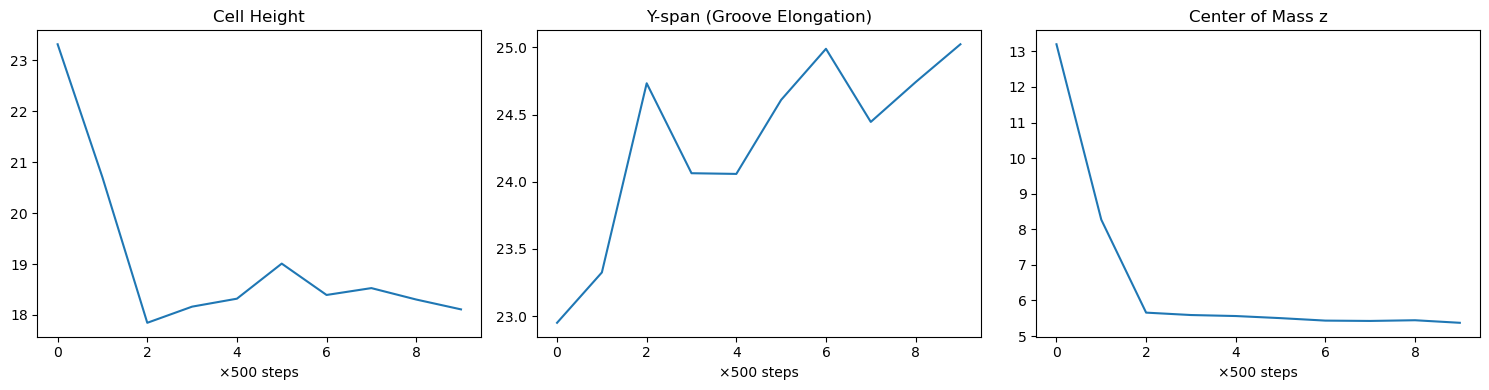

In [20]:
# 第二步开始descent
if __name__ == "__main__":
    main_phase2_descent()

In [ ]:
def main_phase2():
    # 创建新 cell（建立网格拓扑结构）
    cell = VirtualCell()
    
    # ★ 加载 Phase 1 的状态 ★
    cell.load_state("phase1_checkpoint.npz")
    
    # 进入 Phase 2
    cell.place_cell_above_substrate(clearance=0.5)
    
    print(">>> Phase 2 >>>")
    steps = 8000
    history_h, history_y = [], []
    for i in range(steps):
        cell.step()
        if i % 500 == 0:
            h = np.max(cell.positions[cell.idx_mem, 2])
            yspan = np.max(cell.positions[cell.idx_mem, 1]) - np.min(cell.positions[cell.idx_mem, 1])
            history_h.append(h)
            history_y.append(yspan)
            print(f"Phase2 Step {i:4d} | Height={h:6.2f} | Y-span={yspan:6.2f}")

    # 可视化
    fig = visualize_cell(cell)
    fig.write_html(f"VirtualCell_{version}_{datetime.now().strftime('%m%d%H%M')}.html")
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1); plt.plot(history_h); plt.title("Settling Height")
    plt.subplot(1,2,2); plt.plot(history_y); plt.title("Groove Elongation")
    plt.show()


In [ ]:
# 第二步开始
if __name__ == "__main__":
    main_phase2()

In [ ]:
def main():
    cell = VirtualCell()
    cell.diagnose_cyto_mem_interaction()
    cell.diagnose_force_components()
    monitor = EquilibriumMonitor(cell, window_size=100)
    
    # === Phase 1: 悬浮完全平衡（论文 100,000 步）===
    print(">>> Phase 1: Equilibration in suspension...")

    #max_steps = 8000
    check_interval = 500
    for i in range(6000):
        cell.step()
        
        monitor.compute_metrics()
        
        if i > 0 and i % check_interval == 0:
            metrics = monitor.compute_metrics()
            cell.diagnose_force_components()
            cell.diagnose_shape()
            cell.diagnose_forces()
            print(f"Step {i:5d} | F_max={metrics['F_max']:6.2f} | "
                  f"V/V0={metrics['V_ratio']:.3f} | Ψ={metrics['sphericity']:.3f}")
            #cell.diagnose_cyto_mem_interaction()
            
            if monitor.is_equilibrated(verbose=False):
                print(f"\n✓ Equilibrium reached at step {i}")
                break
    # 最终检查与可视化
    monitor.is_equilibrated(verbose=True)
    monitor.plot_convergence()

    #保存阶段1状态
    cell.save_state("phase1_checkpoint.npz")
    # === Phase 2: 放置 + 正常模拟 ===
    #if monitor.is_equilibrated(verbose=False):
    '''
    cell.place_cell_above_substrate(clearance=0.5)
    
    steps = 4000
    history_h, history_y = [], []
    print(">>> Phase 2: Running with substrate...")
    for i in range(steps):
        cell.step()
        if i % 1000 == 0:
            h = np.max(cell.positions[cell.idx_mem, 2])
            yspan = np.max(cell.positions[cell.idx_mem, 1]) - np.min(cell.positions[cell.idx_mem, 1])
            history_h.append(h)
            history_y.append(yspan)
            print(f"Phase2 Step {i:4d} | Height={h:6.2f} | Y-span={yspan:6.2f}")
    
    # 可视化
    fig = visualize_cell(cell)
    fig.write_html(f"VirtualCell_{version}_{datetime.now().strftime('%m%d%H%M')}.html")
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1); plt.plot(history_h); plt.title("Settling Height")
    plt.subplot(1,2,2); plt.plot(history_y); plt.title("Groove Elongation")
    plt.show()
    '''

In [ ]:
if __name__ == "__main__":
    main()